<div dir="rtl">

# مختبر إثرائي — خوارزمية جروفر بالبناء التدريجي

**QSilver39 · مادة إثرائية · يرافق الملف التفاعلي `qsilver-grover-ar.html`**

هذا الدفتر ينفذ رحلة الملف التفاعلي نفسها، محطةً محطة، لكن بأداة مختلفة: هنا **تُشغّل الشيفرة وتعدّلها وتكسرها وتعيد تشغيلها**. القاعدة الملتزمة في الدفتر كله:

> **كل ادعاء عددي يرافقه سطر `assert` يتحقق منه** — لا نكتفي بقول «الاحتمال 96.1٪» بل نطالب الحاسوب بإثباته في كل تشغيل.

المتطلبات: `qiskit` و `qiskit-aer` و `numpy` و `matplotlib`. حجم المسألة 4 كيوبتات (قائمة من 16) مطابقًا للملف التفاعلي.

**اتفاقان:** (1) نصوص المخططات بالإنجليزية عمدًا — عرض العربية داخل matplotlib يتطلب تجهيز خطوط غير متوفر عادة على أجهزة المتدربين. (2) نعتمد اتفاق Qiskit الداخلي: **الكيوبت رقم 0 هو أدنى خانة** في فهرس الحالة (يختلف عن اتفاق دفاتر تقدير الطور حيث `control[0]` أعلى خانة).

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

# Extra Lab — Grover's Algorithm, built and verified step by step

**QSilver39 · enrichment material · companion to the interactive file `qsilver-grover-ar.html`**

This notebook walks the same journey as the interactive file, station by station, but with a different instrument: here you **run the code, modify it, break it, and re-run it**. One rule holds throughout:

> **Every numerical claim is accompanied by an `assert` that checks it** — we never just say "96.1%"; we make the computer prove it on every run.

Requirements: `qiskit`, `qiskit-aer`, `numpy`, `matplotlib`. Problem size is 4 qubits (a list of 16), matching the interactive file.

**Two conventions:** (1) plot text is deliberately English-only — Arabic inside matplotlib needs font setup trainees usually lack. (2) We use Qiskit's native ordering: **qubit 0 is the least-significant bit** of the state index (unlike the phase-estimation notebooks, where `control[0]` is the most-significant bit).

</div>

In [6]:
# ============================================================
# Imports, palette, and global constants
# [AR] الاستيرادات ولوحة الألوان والثوابت العامة للدفتر كله
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from math import asin, sin, pi, sqrt, atan2, degrees

# Color palette copied from the interactive HTML files, so the two
# instruments share one visual language:
INK    = "#1C2340"   # main text/ink color
WAVE   = "#17916C"   # green  = ordinary amplitudes
MIRROR = "#C4551F"   # orange = the marked (solution) state
PIN    = "#B87514"   # gold   = the mean line (inversion mirror)
ANGLE  = "#6C63D8"   # purple = theory curves / the state arrow

n = 4                # number of qubits
N = 2**n             # list length: 16 states
rng = np.random.default_rng(7)   # seeded -> every run reproduces the same numbers
print(f"n = {n} qubits  ->  N = {N} states")

n = 4 qubits  ->  N = 16 states


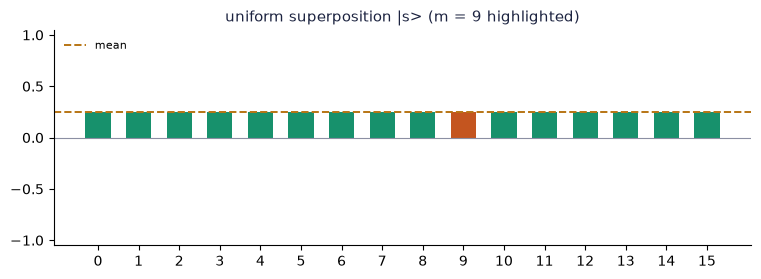

In [7]:
# ============================================================
# show_state(): the one plotting helper used after EVERY step
# [AR] دالة العرض الموحدة: أعمدة موقعة + خط المتوسط الذهبي — لغة الملف التفاعلي البصرية
# ============================================================
def show_state(v, m=None, title="", ax=None):
    """Signed amplitude bars + gold mean line (the HTML files' visual language).
    v  : real state vector (amplitudes, may be negative)
    m  : index of the marked state -> drawn in orange
    [AR] v متجه السعات الحقيقي، m موضع الحل (يُرسم برتقاليًا)"""
    v = np.real_if_close(np.asarray(v))          # drop ~0 imaginary parts safely
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 2.8))
    # one bar per basis state; the marked state gets the orange color:
    colors = [MIRROR if k == m else WAVE for k in range(len(v))]
    ax.bar(range(len(v)), v, color=colors, width=0.62)
    # the gold dashed line is the amplitude MEAN - the mirror of the diffusion step:
    ax.axhline(v.mean(), color=PIN, lw=1.4, ls="--", label="mean")
    ax.axhline(0, color="#8B8FA3", lw=0.8)       # zero axis, since bars are signed
    ax.set_xticks(range(len(v)))
    ax.set_ylim(-1.05, 1.05)
    ax.set_title(title, fontsize=11, color=INK)
    ax.legend(loc="upper left", fontsize=8, frameon=False)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    return ax

# quick self-test: the uniform superposition, with state 9 highlighted
show_state(np.full(N, 1/sqrt(N)), m=9, title="uniform superposition |s> (m = 9 highlighted)")
plt.show()

<div dir="rtl">

---
## المحطة الأولى — البحث الكلاسيكي: قِس الكلفة بنفسك

في الملف التفاعلي لعبتَ لعبة الصناديق مرة واحدة. هنا نلعبها **عشرة آلاف مرة** ونقيس المتوسط — الفارق الذي تتيحه الشيفرة: الإحصاء بدل الانطباع.

### المهمة 1
اكتب دالة `classical_search(secret)` تفحص المواضع بترتيب عشوائي وتعيد عدد الفحوص حتى إيجاد `secret`، ثم شغّلها 10000 مرة واحسب المتوسط. ما القيمة المتوقعة نظريًا؟

<details><summary>الحل | Solution</summary>

المتوسط النظري لفحص قائمة طولها 16 بترتيب عشوائي هو (N+1)/2 = 8.5 — والخلية التالية تنفذه وتتحقق.
The theoretical mean for probing a 16-item list in random order is (N+1)/2 = 8.5 — the next cell implements and verifies this.
</details>

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 1 — Classical search: measure the cost yourself

In the interactive file you played the boxes game once. Here we play it **ten thousand times** and measure the average — the advantage code gives us: statistics instead of impressions.

### Task 1
Write `classical_search(secret)` that probes positions in random order and returns the number of probes until `secret` is found; run it 10,000 times and compute the mean. What value does theory predict?

</div>

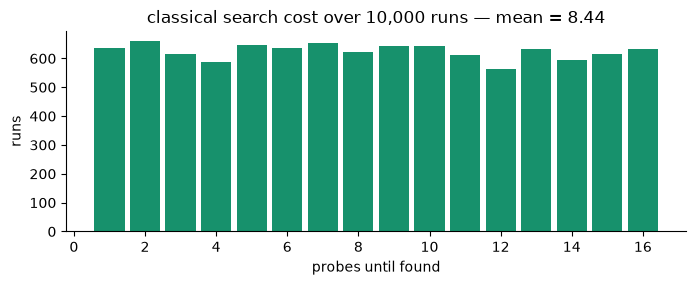

verified: mean 8.44 matches theory 8.5
Grover's promise for N=16: 3 oracle calls, then ONE measurement at 96.1% - let's earn these numbers.


In [8]:
# ============================================================
# Station 1: classical search cost, measured over 10,000 runs
# [AR] كلفة البحث الكلاسيكي مقيسة إحصائيًا — المتوسط النظري (N+1)/2
# ============================================================
def classical_search(secret, N=16):
    """Probe positions in random order; return #probes until 'secret' is found.
    [AR] فحص المواضع بترتيب عشوائي حتى إيجاد الهدف، وإعادة عدد الفحوص"""
    order = rng.permutation(N)                    # a random probing order
    for probes, pos in enumerate(order, start=1): # count probes starting at 1
        if pos == secret:
            return probes

# 10,000 independent games, each with a fresh random secret:
trials = np.array([classical_search(rng.integers(N)) for _ in range(10_000)])

fig, ax = plt.subplots(figsize=(8, 2.6))
ax.hist(trials, bins=np.arange(0.5, N + 1.5), color=WAVE, rwidth=0.85)
ax.set_xlabel("probes until found"); ax.set_ylabel("runs")
ax.set_title(f"classical search cost over 10,000 runs — mean = {trials.mean():.2f}")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.show()

# CLAIM: the average classical cost is (N+1)/2 = 8.5. Prove it:
assert abs(trials.mean() - (N + 1) / 2) < 0.15, trials.mean()
print(f"verified: mean {trials.mean():.2f} matches theory {(N+1)/2}")
print(f"Grover's promise for N={N}: 3 oracle calls, then ONE measurement at 96.1% - let's earn these numbers.")

<div dir="rtl">

---
## المحطة الثانية — دالة الوسم: علامة لا يراها القياس

دالة الوسم (Oracle) تنفذ المعادلة \(U_f|x\rangle = (-1)^{f(x)}|x\rangle\): قلب إشارة سعة الحل وحده. الادعاء المركزي في الملف التفاعلي كان: **الوسم لا يغيّر أي احتمال**. هنا لا نكتفي بقوله — نطالب `assert` بإثباته.

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 2 — The oracle: a mark measurement cannot see

The oracle implements \(U_f|x\rangle = (-1)^{f(x)}|x\rangle\): it flips the sign of the solution's amplitude only. The interactive file's central claim was: **marking changes no probability**. Here we don't just say it — we make an `assert` prove it.

</div>

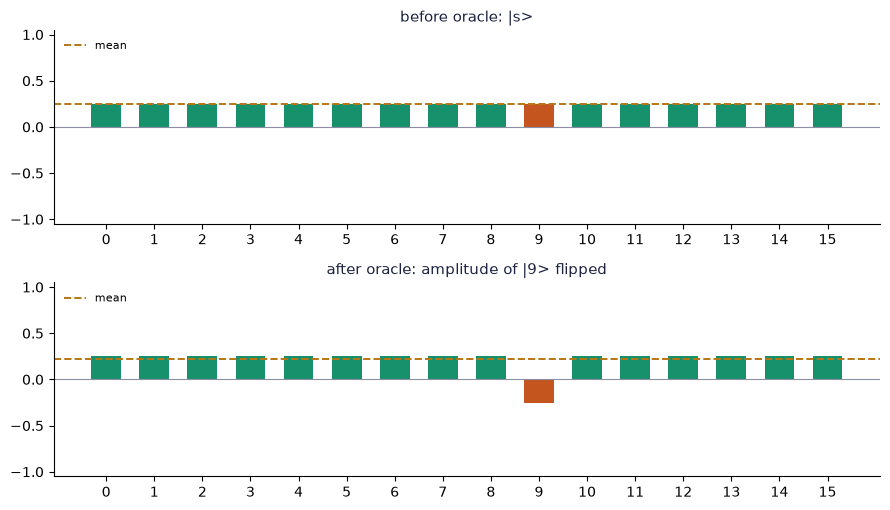

verified: probabilities identical before/after marking; oracle^2 = identity


In [9]:
# ============================================================
# Station 2a: the oracle as a numpy operation + its two key properties
# [AR] دالة الوسم على متجه numpy وإثبات خاصيتيها: لا تغيّر الاحتمالات، وتعكس نفسها
# ============================================================
m = 9                                  # the marked state (solution), as in the HTML file

s_state = np.full(N, 1/sqrt(N))        # |s>: the uniform superposition, amplitude 1/4 each

def oracle_np(v, m):
    """Phase oracle on a numpy state vector: flip the sign of amplitude m.
    [AR] قلب إشارة سعة الحل وحدها — وسمٌ بالطور"""
    out = v.copy()                     # never mutate the caller's state
    out[m] = -out[m]                   # the entire oracle is this one sign flip
    return out

marked = oracle_np(s_state, m)

fig, axes = plt.subplots(2, 1, figsize=(9, 5.2))
show_state(s_state, m, "before oracle: |s>", axes[0])
show_state(marked,  m, "after oracle: amplitude of |9> flipped", axes[1])
plt.tight_layout(); plt.show()

# CLAIM 1: the mark is invisible to measurement (probabilities = squared amplitudes):
assert np.allclose(s_state**2, marked**2)
# CLAIM 2: the oracle is its own inverse (applying it twice restores the state):
assert np.allclose(oracle_np(marked, m), s_state)
print("verified: probabilities identical before/after marking; oracle^2 = identity")

<div dir="rtl">

### المهمة 2 — بناء دالة الوسم دائرةً حقيقية

في الملف التفاعلي رأيت البناء الداخلي: بوابات X توجه الحل إلى \(|1111\rangle\) فيقلب \(CCCZ\) إشارتها ثم تعيد X الترتيب. ابنِ الدالة `oracle_circuit(m)` في Qiskit، ثم **أثبت** أن مصفوفتها تطابق مؤثر numpy أعلاه تمامًا.

<details><summary>الحل | Solution</summary>

ضع X على كل كيوبت خانته في m تساوي صفرًا (باتفاق الكيوبت 0 = أدنى خانة)، ثم `ZGate().control(3)`، ثم X نفسها. الخلية التالية تبنيها وتتحقق بمقارنة `Operator` كاملة.
Put X on every qubit whose bit of m is 0 (qubit 0 = LSB), then `ZGate().control(3)`, then the same X gates. The next cell builds it and verifies via a full `Operator` comparison.
</details>

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

### Task 2 — Build the oracle as a real circuit

The interactive file showed the internals: X gates route the solution to \(|1111\rangle\), \(CCCZ\) flips that state's sign, and the X gates route back. Build `oracle_circuit(m)` in Qiskit, then **prove** its matrix equals the numpy operator above exactly.

</div>

verified: circuit unitary == diag(1,...,-1@9,...,1) exactly


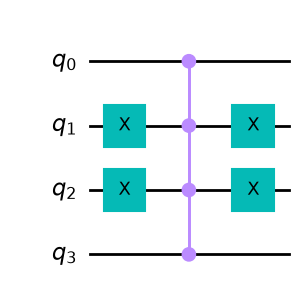

In [10]:
# ============================================================
# Station 2b: the oracle as gates, verified against the exact matrix
# [AR] دالة الوسم من البوابات: X توجّه الحل إلى |1111> فيقلبه CCCZ ثم تعيد X الترتيب
# ============================================================
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZGate
from qiskit.quantum_info import Operator, Statevector

def oracle_circuit(m, n=4):
    """X-route m to |11..1>, flip its sign with a multi-controlled Z, X-route back.
    [AR] التوجيه فالقلب فالإرجاع — البناء الداخلي من الملف التفاعلي حرفيًا"""
    qc = QuantumCircuit(n, name=f"U_f(m={m})")
    # qubits whose bit in m is 0 need an X so that |m> arrives at |11..1>:
    zeros = [q for q in range(n) if not (m >> q) & 1]   # qubit q <-> bit q (little-endian)
    for q in zeros: qc.x(q)                             # route in
    qc.append(ZGate().control(n - 1), list(range(n)))   # CCCZ: flips |11..1> only
    for q in zeros: qc.x(q)                             # route back
    return qc

U_oracle = Operator(oracle_circuit(m)).data             # full 16x16 unitary of the circuit

# the exact matrix the oracle MUST equal: identity with a single -1 at (m, m):
U_expected = np.eye(N); U_expected[m, m] = -1

# CLAIM: the gate construction implements the phase flip exactly (no approximation):
assert np.allclose(U_oracle, U_expected)
print(f"verified: circuit unitary == diag(1,...,-1@{m},...,1) exactly")
oracle_circuit(m).draw("mpl", style="clifford")

<div dir="rtl">

---
## المحطة الثالثة — هندسة المسألة: التعامد والزاوية الصغيرة

المستوى الذي تعيش فيه الخوارزمية يمدّه متجهان متعامدان: الحل \(|m\rangle\) وحالة الإجابات الخاطئة \(|B\rangle = \frac{1}{\sqrt{15}}\sum_{x\neq m}|x\rangle\). وحالة البداية تتحلل:

$$|s\rangle = \sin(\theta/2)\,|m\rangle + \cos(\theta/2)\,|B\rangle,\qquad \sin(\theta/2)=\tfrac{1}{\sqrt{N}}=\tfrac14$$

الخلية التالية تبني المتجهين وتتحقق من كل بند في هذا الكلام.

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 3 — The geometry: orthogonality and the small angle

The plane the algorithm lives in is spanned by two orthogonal vectors: the solution \(|m\rangle\) and the wrong-answers state \(|B\rangle = \frac{1}{\sqrt{15}}\sum_{x\neq m}|x\rangle\). The starting state decomposes as above with \(\sin(\theta/2)=1/4\). The next cell builds both vectors and verifies every clause of that sentence.

</div>

In [11]:
# ============================================================
# Station 3: build |m>, |B>, verify orthonormality, decomposition, and the angle
# [AR] بناء متجهي المستوى والتحقق من التعامد والتحلل والزاوية 14.48 درجة
# ============================================================
ket_m = np.zeros(N); ket_m[m] = 1                 # the solution axis
ket_B = np.ones(N) / sqrt(N - 1); ket_B[m] = 0    # equal weight on the 15 wrong answers

theta = 2 * asin(1 / sqrt(N))                     # the per-iteration rotation angle

# CLAIM 1: |m> and |B> are orthonormal (no shared basis state -> inner product 0):
assert abs(ket_m @ ket_B) < 1e-12 and abs(ket_B @ ket_B - 1) < 1e-12
# CLAIM 2: |s> decomposes EXACTLY as sin(theta/2)|m> + cos(theta/2)|B>:
assert np.allclose(s_state, sin(theta/2) * ket_m + np.cos(theta/2) * ket_B)
# CLAIM 3: the starting angle above the |B> axis is 14.48 degrees:
assert abs(degrees(theta/2) - 14.4775) < 1e-3

def plane_coords(v, m):
    """Project a (real) state onto the |B>,|m> plane -> (a_B, a_m).
    [AR] إسقاط الحالة على المستوى: المركّبتان على محوري الخاطئة والحل"""
    return float(ket_B @ v), float(v[m])

aB, aM = plane_coords(s_state, m)
print(f"theta/2 = {degrees(theta/2):.3f} deg | |s> = ({aB:.4f})|B> + ({aM:.4f})|m>")
print(f"direct-measurement success from |s>: {aM**2:.4f} = 1/{N}")

theta/2 = 14.478 deg | |s> = (0.9682)|B> + (0.2500)|m>
direct-measurement success from |s>: 0.0625 = 1/16


<div dir="rtl">

---
## المحطة الرابعة — انعكاسان يصنعان دورانًا

مؤثر الانعكاس \(D = 2|s\rangle\langle s| - I\) يعكس أي حالة حول خط \(|s\rangle\)، وصيغته سعةً سعة هي «الانعكاس حول المتوسط» \(a \leftarrow 2\mu - a\). ثلاثة ادعاءات من الملف التفاعلي، ثلاثة `assert`:

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 4 — Two reflections make one rotation

The diffusion operator \(D = 2|s\rangle\langle s| - I\) reflects any state about the \(|s\rangle\) line; amplitude-by-amplitude it is "inversion about the mean", \(a \leftarrow 2\mu - a\). Three claims from the interactive file, three `assert`s:

</div>

In [ ]:
# ============================================================
# Station 4: D as a matrix vs the mean formula; oracle as a reflection; iteration 1
# [AR] مطابقة المصفوفة مع صيغة المتوسط، والوسم انعكاسًا حول |B>، وأرقام الدورة الأولى
# ============================================================
D_concept = 2 * np.outer(s_state, s_state) - np.eye(N)   # D = 2|s><s| - I, explicitly

def reflect_mean(v):
    """Inversion about the mean, amplitude by amplitude: a -> 2*mean - a.
    [AR] الانعكاس حول المتوسط سعةً سعة"""
    return 2 * v.mean() - v

# CLAIM 1: the matrix D and the mean formula are the SAME operation.
# We test on a random probe vector - one success on random input is strong evidence:
probe = rng.normal(size=N); probe /= np.linalg.norm(probe)
assert np.allclose(D_concept @ probe, reflect_mean(probe))

# CLAIM 2: the oracle is a reflection about |B>:
# it must keep the B-component and flip the m-component. Check both projections:
aB0, aM0 = plane_coords(s_state, m)                 # before
aB1, aM1 = plane_coords(oracle_np(s_state, m), m)   # after the oracle
assert abs(aB1 - aB0) < 1e-12 and abs(aM1 + aM0) < 1e-12

# CLAIM 3: one full iteration (oracle then D) lands at the HTML file's exact numbers:
after1 = reflect_mean(oracle_np(s_state, m))
assert abs(after1[m] - 0.6875) < 1e-4               # amplitude 0.6875
assert abs(after1[m]**2 - 0.4727) < 1e-4            # probability 47.27%

fig, axes = plt.subplots(2, 1, figsize=(9, 5.2))
show_state(oracle_np(s_state, m), m, "after oracle: marked amplitude below the mean", axes[0])
show_state(after1, m, f"after inversion about the mean: a[m] = {after1[m]:.4f}, P = {after1[m]**2:.1%}", axes[1])
plt.tight_layout(); plt.show()
print("verified: D == mean-inversion; oracle == reflection about |B>; one iteration -> 47.3%")

<div dir="rtl">

---
## اكتشاف — ابنِ العاكس من البوابات ثم اختبره

في الملف التفاعلي قيل لك إن تركيب \(H^{\otimes 4}\, X^{\otimes 4}\, CCCZ\, X^{\otimes 4}\, H^{\otimes 4}\) ينفذ الانعكاس \(D\). **الخلية التالية تختبر هذا الادعاء كما هو — وستفشل.** لا تتجاوز الفشل: هذه هي التجربة.

### المهمة 3
شغّل الخلية، اقرأ رسالة الفشل، ثم افحص بنفسك العلاقة بين المصفوفتين (جرّب طباعة `U_gate[0,0]` و `D_concept[0,0]`). ما العلاقة الدقيقة؟ ولماذا لا يهم ذلك فيزيائيًا؟

<details><summary>الحل | Solution</summary>

المصفوفة المبنية من البوابات تساوي \(-D\) بالضبط: التركيب يحمل طورًا كليًا \(-1\). الطور الكلي لا يغيّر أي احتمال قياس، والدورة الثانية تضرب \(-1\) أخرى فيلغيان بعضهما.
The gate-built matrix equals \(-D\) exactly: the construction carries a global phase of \(-1\). A global phase changes no measurement probability, and the second iteration contributes another \(-1\), cancelling it.
</details>

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Discovery — build the diffuser from gates, then test it

The interactive file told you that \(H^{\otimes 4}\, X^{\otimes 4}\, CCCZ\, X^{\otimes 4}\, H^{\otimes 4}\) implements \(D\). **The next cell tests that claim as stated — and it will fail.** Don't skip past the failure: the failure *is* the experiment.

### Task 3
Run the cell, read the failure, then investigate the relation between the two matrices yourself (try printing `U_gate[0,0]` vs `D_concept[0,0]`). What is the exact relation, and why is it physically harmless?

</div>

In [ ]:
# ============================================================
# Discovery: the gate-built diffuser vs 2|s><s| - I  (this test FAILS on purpose)
# [AR] بناء العاكس من البوابات واختباره — الفشل مقصود، والتحقيق هو الدرس
# ============================================================
def diffusion_circuit(n=4):
    """H-wall, X-wall, CCCZ, X-wall, H-wall: reflection about |0..0> conjugated
    by Hadamards = reflection about |s>  ... up to something you are about to find.
    [AR] انعكاس حول |0000> بين جداري هادامارد — مع ما ستكتشفه بعد قليل"""
    qc = QuantumCircuit(n, name="D?")
    qc.h(range(n)); qc.x(range(n))
    qc.append(ZGate().control(n - 1), list(range(n)))   # flips |1111> only
    qc.x(range(n)); qc.h(range(n))
    return qc

U_gate = np.real_if_close(Operator(diffusion_circuit()).data)

# --- the naive claim, tested exactly as the file stated it: ---
try:
    assert np.allclose(U_gate, D_concept), "gate-built operator != 2|s><s| - I"
    print("matched directly (unexpected!)")
except AssertionError as e:
    print("ASSERTION FAILED (as intended):", e)
    # first clue for the investigation - compare one matrix entry:
    print("investigate: U_gate[0,0] =", round(U_gate[0,0].real, 4),
          " vs  D_concept[0,0] =", round(D_concept[0,0], 4))

# --- after investigating (Task 3), the TRUE relation, asserted: ---
assert np.allclose(U_gate, -D_concept)
print("verified: the gate construction equals  -D  exactly - a global phase of -1")

# --- and the physical harmlessness of that phase, as its own assertion: ---
v = D_concept @ s_state       # ideal diffusion
w = U_gate @ s_state          # gate-built diffusion (= -D)
assert np.allclose(np.abs(v)**2, np.abs(w)**2)   # same measurement distribution
print("verified: measurement distributions of D|psi> and (-D)|psi> are identical")

<div dir="rtl">

---
## المحطة الخامسة — الدائرة كاملة: ابنِ، أضف خطوة، اعرض

الآن البناء التدريجي: دالة تبني دائرة جروفر حتى «كتلة» معينة، وحلقة تعرض الحالة بعد كل كتلة — الأعمدة الموقعة **وزاوية السهم في المستوى** معًا، كما في العارض المتزامن للملف التفاعلي.

انتبه لما ستراه: بعد العاكس الأول والثالث تقفز زاوية المستوى بمقدار 180° وتنقلب الأعمدة كلها — **هذا الطور الكلي من قسم الاكتشاف يظهر حيًا**، يظهر بعد كل عاكس ويُلغى مع الذي يليه. الخلية التي بعد العرض تثبت العلاقة بدقة بدل أن تتجاهلها.

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 5 — The full circuit: build, add a block, display

Now the incremental build: a function that constructs the Grover circuit up to a given *block*, and a loop that displays the state after each block — signed bars **and the plane angle** together, like the interactive file's synchronized viewer.

Watch for it: after the first and third diffusers the plane angle jumps by 180° and all bars flip sign — **the global phase from the Discovery section, live**: it appears after every diffuser and cancels with the next. The cell after the display proves the relation precisely instead of ignoring it.

</div>

In [ ]:
# ============================================================
# Station 5a: incremental construction + the 8-panel synchronized display
# [AR] البناء التدريجي: كتلة فعرض، مع زاوية المستوى واحتمال الحل فوق كل لوحة
# ============================================================
def grover_upto(m, blocks, n=4):
    """Build the Grover circuit up to a given number of blocks.
    block 0 = nothing (input), block 1 = H wall, then alternating oracle/diffusion.
    [AR] بناء الدائرة حتى كتلة معينة: جدار H ثم تناوب وسم/عاكس"""
    qc = QuantumCircuit(n)
    if blocks >= 1: qc.h(range(n))                       # block 1: H wall -> |s>
    for b in range(1, blocks):
        if b % 2 == 1: qc.compose(oracle_circuit(m, n), inplace=True)   # odd  -> oracle
        else:          qc.compose(diffusion_circuit(n),  inplace=True)  # even -> diffuser
    return qc

labels = ["input |0000>", "H wall -> |s>",
          "oracle 1", "diffusion 1", "oracle 2", "diffusion 2", "oracle 3", "diffusion 3"]

angles = []                                              # raw circuit plane angles per block
fig, axes = plt.subplots(8, 1, figsize=(9, 17))
for blocks, (lab, ax) in enumerate(zip(labels, axes)):
    # exact statevector of the partial circuit (this is a real simulation, not a sketch):
    v = np.real_if_close(Statevector(grover_upto(m, blocks)).data)
    aB, aM = plane_coords(v, m)                          # project onto the |B>,|m> plane
    ang = degrees(atan2(aM, aB))
    angles.append(round(ang, 1))
    show_state(v, m, f"{lab}   |   plane angle = {ang:+.1f} deg,  P(m) = {aM**2:.1%}", ax)
plt.tight_layout(); plt.show()

print("angle sequence:", angles[1:])   # note the +-180-degree jumps after diffusers 1 and 3

In [ ]:
# ============================================================
# Station 5b: phase-aware verification of the whole sequence
# The circuit state equals (-1)^d times the concept state, where d = number of
# gate-built diffusers applied so far. This quantifies the Discovery exactly.
# [AR] التحقق الواعي بالطور: حالة الدائرة = (-1)^d ضرب الحالة المفاهيمية عند كل كتلة
# ============================================================
def concept_upto(blocks):
    """Concept-level evolution (numpy, clean D) + count d of diffusions applied.
    [AR] التطور المفاهيمي بالعاكس النظيف مع عدّ العواكس d"""
    v = np.zeros(N); v[0] = 1
    d = 0
    if blocks >= 1: v = np.full(N, 1/sqrt(N))
    for b in range(1, blocks):
        if b % 2 == 1: v = oracle_np(v, m)
        else:          v = reflect_mean(v); d += 1
    return v, d

folded = []                                   # concept angles = phase-folded angles
for blocks in range(1, 8):
    v_circ = np.real_if_close(Statevector(grover_upto(m, blocks)).data)
    v_con, d = concept_upto(blocks)
    # CLAIM 1: circuit == (-1)^d * concept, exactly, at every block:
    assert np.allclose(v_circ, ((-1) ** d) * v_con), f"block {blocks}"
    # CLAIM 2: probabilities never see the phase:
    assert np.allclose(v_circ ** 2, v_con ** 2)
    aB, aM = plane_coords(v_con, m)
    folded.append(round(degrees(atan2(aM, aB)), 1))

# CLAIM 3: with the phase folded out, the sequence is exactly +-(2k+1) * theta/2:
th2 = degrees(theta / 2)
expected = [round(a, 1) for a in (th2, -th2, 3*th2, -3*th2, 5*th2, -5*th2, 7*th2)]
assert folded == expected, (folded, expected)

# CLAIM 4: the final success probability is the file's 96.13%:
final = np.real_if_close(Statevector(grover_upto(m, 8)).data)
assert abs(final[m] ** 2 - 0.9613) < 1e-4
print("raw circuit angles :", angles[1:])
print("phase-folded angles:", folded, " == +-(2k+1)*theta/2")
print(f"verified: circuit == (-1)^d x concept at every block, and P(m) after 3 iterations = {final[m]**2:.4f}")

<div dir="rtl">

---
## المحطة السادسة — مصدر الجذر: نظريةً ثم قياسًا

نظريًا \(P(k) = \sin^2\big((2k+1)\theta/2\big)\) وقمتها عند \(k_{opt} = \lfloor\frac{\pi}{4}\sqrt{N}\rfloor\). الخلية الأولى ترسم المنحنى وتتحقق من قيم الملف التفاعلي (96.1٪ عند 3، والهبوط إلى 12.5٪ عند 5). والخلية الثانية تفعل ما لا يستطيعه المتصفح: **تقيس قانون الجذر تجريبيًا** عبر أحجام من 4 حالات إلى 1024.

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 6 — Where the square root comes from: theory, then measurement

Theory says \(P(k) = \sin^2\big((2k+1)\theta/2\big)\), peaking at \(k_{opt} = \lfloor\frac{\pi}{4}\sqrt{N}\rfloor\). The first cell plots the curve and verifies the interactive file's values (96.1% at 3, dropping to 12.5% at 5). The second cell does what a browser cannot: it **measures the square-root law empirically** across sizes from 4 to 1024 states.

</div>

In [ ]:
# ============================================================
# Station 6a: the P(k) curve + the interactive file's two checkpoint values
# [AR] منحنى الاحتمال مقابل عدد الدورات والتحقق من قيمتي الملف: القمة والهبوط
# ============================================================
def P_theory(k, N):
    """Success probability after k iterations: sin^2((2k+1) * theta/2).
    [AR] احتمال النجاح النظري بعد k دورة"""
    th = 2 * asin(1 / sqrt(N))
    return sin((2*k + 1) * th / 2) ** 2

ks = np.arange(0, 9)
Ps = [P_theory(k, N) for k in ks]

fig, ax = plt.subplots(figsize=(8, 3))
kk = np.linspace(0, 8, 200)
ax.plot(kk, [P_theory(k, N) for k in kk], color=ANGLE, alpha=0.6)   # continuous sinusoid
ax.plot(ks, Ps, "o", color=WAVE, ms=7)                              # integer iterations
ax.plot(3, Ps[3], "o", color=MIRROR, ms=11)                         # the peak, k = 3
ax.set_xlabel("iterations k"); ax.set_ylabel("P(m)")
ax.set_title("success probability vs iterations, N = 16 - peak at k = 3, then over-rotation")
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.show()

# CLAIM: the two checkpoint values from the interactive file (exact to 4 decimals):
assert abs(Ps[3] - 0.96132) < 1e-4 and abs(Ps[5] - 0.12549) < 1e-4
print(f"verified: P(3) = {Ps[3]:.1%}, P(5) = {Ps[5]:.1%} - more iterations can hurt")

In [ ]:
# ============================================================
# Station 6b: the square-root law, MEASURED (browser-impossible)
# [AR] قياس قانون الجذر تجريبيًا: القمة الأولى مقابل (pi/4) جذر N حتى 1024 حالة
# ============================================================
def best_k(n_q):
    """k of the FIRST probability peak. (Later revolutions of the sinusoid can
    occasionally align slightly closer to 90 degrees, but cost linearly more
    oracle calls - the sqrt-law statement is about the first peak.)
    [AR] أول قمة للاحتمال — دورات لاحقة قد تصطف أدق قليلًا لكن بكلفة خطية أكبر"""
    Nq = 2 ** n_q
    v = np.full(Nq, 1 / sqrt(Nq)); mm = 0     # marked state 0, WLOG
    prev = v[mm] ** 2
    for k in range(1, 4 * int(sqrt(Nq)) + 4):
        v[mm] = -v[mm]                # oracle: one sign flip
        v = 2 * v.mean() - v          # diffusion: inversion about the mean
        p = v[mm] ** 2
        if p < prev:                  # first decrease -> previous k was the peak
            return k - 1
        prev = p
    return k

ns = range(2, 11)                                    # 4 .. 1024 states
measured  = [best_k(q) for q in ns]                  # simulated optimum
predicted = [pi / 4 * sqrt(2 ** q) for q in ns]      # the formula

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot([sqrt(2**q) for q in ns], measured, "o-", color=WAVE, label="measured optimal k")
ax.plot([sqrt(2**q) for q in ns], predicted, "--", color=MIRROR, label="(pi/4) sqrt(N)")
ax.set_xlabel("sqrt(N)"); ax.set_ylabel("optimal k")
ax.set_title("the square-root law, measured: optimal iterations vs sqrt(N)")
ax.legend(frameon=False)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.show()

# CLAIM: the measured first-peak optimum tracks the formula within +-1 everywhere:
assert all(abs(mk - pk) <= 1 for mk, pk in zip(measured, predicted))
print("verified: optimal k tracks (pi/4)sqrt(N) within +-1 across N = 4 .. 1024")

<div dir="rtl">

---
## المحطة السابعة — القياس الحقيقي: عدد الرميات يصنع الفرق

المتصفح عرض التوزيع الصافي؛ المحاكي هنا **يقيس فعلًا**. قارن مئة قياس بعشرة آلاف — هذا مفهوم «التقدير الإحصائي» الذي لا يظهر إلا بالتنفيذ:

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Station 7 — Real measurement: shot count matters

The browser displayed the clean distribution; the simulator here **actually measures**. Compare one hundred shots with ten thousand — statistical estimation, a concept only execution can show:

</div>

In [ ]:
# ============================================================
# Station 7: AerSimulator with shots - 100 (noisy) vs 10,000 (converged)
# [AR] القياس الفعلي بالمحاكي: مئة رمية مشوشة مقابل عشرة آلاف متقاربة من النظرية
# ============================================================
from qiskit import transpile
from qiskit_aer import AerSimulator
sim = AerSimulator()

qc = grover_upto(m, 8)                 # the full 3-iteration circuit
qc_meas = qc.copy(); qc_meas.measure_all()
tqc = transpile(qc_meas, sim)          # adapt the circuit to the simulator backend

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for shots, ax in zip((100, 10_000), axes):
    counts = sim.run(tqc, shots=shots, seed_simulator=11).result().get_counts()
    freq = np.zeros(N)
    for bits, c in counts.items():
        # little-endian pays off here: int(bitstring, 2) IS our state index directly
        freq[int(bits, 2)] = c / shots
    ax.bar(range(N), freq, color=[MIRROR if k == m else WAVE for k in range(N)], width=0.62)
    ax.set_title(f"{shots} shots -> P(m) ~ {freq[m]:.1%}")
    ax.set_ylim(0, 1)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

# CLAIM: at 10,000 shots the measured rate matches theory within statistical error:
counts = sim.run(tqc, shots=10_000, seed_simulator=11).result().get_counts()
hit = sum(c for b, c in counts.items() if int(b, 2) == m) / 10_000
assert abs(hit - 0.9613) < 0.01
print(f"verified: measured success {hit:.1%} matches theory 96.1% within statistical error")

<div dir="rtl">

---
## ما بعد المتصفح (1) — الضجيج: بطاقة «حدود العتاد» تصبح قياسًا

الملف التفاعلي قال إن عتاد اليوم يحدّه الضجيج. هنا نقيس ذلك: نموذج إزالة استقطاب بسيط على البوابات، ومعدل النجاح مقابل شدته:

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Beyond the browser (1) — Noise: the "hardware limits" card becomes a measurement

The interactive file said today's hardware is noise-limited. Here we measure that: a simple depolarizing model on the gates, success rate versus its strength:

</div>

In [ ]:
# ============================================================
# Noise: depolarizing error on 1q and 2q gates, success vs error rate
# [AR] نموذج ضجيج إزالة الاستقطاب: معدل النجاح مقابل شدة خطأ البوابات
# ============================================================
from qiskit_aer.noise import NoiseModel, depolarizing_error

def noisy_success(p1, p2, shots=4000):
    """Run the full Grover circuit under depolarizing noise; return success rate.
    p1: 1-qubit gate error prob | p2: 2-qubit (cx) error prob
    [AR] تشغيل الدائرة كاملة تحت الضجيج وإعادة نسبة إصابة الحل"""
    nm = NoiseModel()
    if p1 > 0: nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ["x", "h", "sx", "rz"])
    if p2 > 0: nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ["cx"])
    nsim = AerSimulator(noise_model=nm)
    # transpile to a hardware-like basis so every abstract gate pays its real cost:
    t = transpile(qc_meas, nsim, basis_gates=["cx", "rz", "sx", "x"], optimization_level=1)
    counts = nsim.run(t, shots=shots, seed_simulator=5).result().get_counts()
    return sum(c for b, c in counts.items() if int(b, 2) == m) / shots

levels = [0.0, 0.001, 0.003, 0.006, 0.01]     # 0% .. 1% single-qubit gate error
rates = [noisy_success(p, 4 * p) for p in levels]   # 2q error = 4x 1q (typical ratio)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot([p * 100 for p in levels], [r * 100 for r in rates], "o-", color=MIRROR)
ax.axhline(100 / N, color="#8B8FA3", ls="--", lw=1, label="random guessing (6.25%)")
ax.set_xlabel("1-qubit gate error (%)  [2-qubit error = 4x]")
ax.set_ylabel("success (%)")
ax.set_title("Grover success vs gate noise - depth turns small errors into large losses")
ax.legend(frameon=False)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.show()

# CLAIM: near-perfect when noiseless, and a large drop by 1% gate error:
assert rates[0] > 0.95 and rates[-1] < rates[0] - 0.25
print(f"verified: {rates[0]:.1%} noiseless -> {rates[-1]:.1%} at 1% gate error - the hardware-limits card, measured")

<div dir="rtl">

## ما بعد المتصفح (2) — الترجمة: كم تكلف CCCZ فعلًا؟

في الرسوم كانت \(CCCZ\) صندوقًا واحدًا. العتاد لا يملك صندوقًا كهذا — يملك بوابات ثنائية. المهمة 4: قبل تشغيل الخلية، خمّن كم بوابة `cx` تحتاجها دائرة جروفر الكاملة بعد الترجمة.

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Beyond the browser (2) — Transpilation: what does CCCZ really cost?

In the diagrams \(CCCZ\) was a single box. Hardware owns no such box — it owns two-qubit gates. Task 4: before running the cell, guess how many `cx` gates the full Grover circuit needs after transpilation.

</div>

In [ ]:
# ============================================================
# Transpilation: decompose to a hardware basis and COUNT the real cost
# [AR] الترجمة إلى بوابات العتاد وعدّ الكلفة الحقيقية لصندوق CCCZ المجرد
# ============================================================
t_basis = transpile(grover_upto(m, 8), basis_gates=["cx", "rz", "sx", "x"], optimization_level=1)
ops = t_basis.count_ops()              # dictionary: gate name -> count
print("gate counts after transpilation:", dict(ops))
print(f"depth: {t_basis.depth()}  |  cx count: {ops.get('cx', 0)}")

# CLAIM: the abstract boxes hide dozens of entangling gates:
assert ops.get("cx", 0) >= 40
print("verified: each abstract CCCZ box hides a substantial 2-qubit-gate cost - "
      "this is where the noise section's losses come from")

<div dir="rtl">

---
## الكشف المعتاد — الصنف الجاهز بعد البناء اليدوي

على عادة الدورة: بعد أن بنيتَ كل شيء بيدك، افتح أداة المكتبة وستجد بنيتك داخلها:

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## The usual reveal — the library class, after the manual build

As is this course's habit: having built everything by hand, open the library tool and find your own construction inside it:

</div>

In [ ]:
# ============================================================
# Reveal: qiskit's GroverOperator vs our oracle + diffuser (up to global phase)
# [AR] الكشف: صنف المكتبة الجاهز يطابق بناءنا اليدوي حتى طور كلي
# ============================================================
from qiskit.circuit.library import GroverOperator

G_lib  = Operator(GroverOperator(oracle_circuit(m))).data          # the library's iterate
G_ours = np.real_if_close(Operator(
    oracle_circuit(m).compose(diffusion_circuit())
).data)                                                             # our oracle then diffuser

# equality up to a global phase <=> |trace(U V^dagger)| equals the dimension N:
overlap = abs(np.trace(G_lib.conj().T @ G_ours))
assert abs(overlap - N) < 1e-6
print("verified: the library GroverOperator equals our oracle+diffusion up to a global phase")

<div dir="rtl">

---
## الخاتمة والمهام الإضافية

الدفتر أثبت آليًا كل أرقام الملف التفاعلي: ثبات الاحتمالات تحت الوسم، تطابق البناء البوابي مع \(-D\)، متتالية الزوايا \(\pm(2k+1)\theta/2\)، القمة 96.1٪ والهبوط بعدها، قانون الجذر مقيسًا حتى N=1024، وأثر الضجيج والترجمة.

### مهام للاستزادة
1. **حلّان موسومان:** عدّل `oracle_np` لوسم حالتين. كيف تتغير \(\theta\)؟ (تلميح: \(\sin(\theta/2)=\sqrt{M/N}\)) — وتحقق بمتتالية الزوايا.
2. **كسر الخوارزمية عمدًا:** طبّق العاكس مرتين متتاليتين بلا وسم بينهما. فسّر الناتج بسطر واحد ثم أثبته بـ `assert`.
3. **جرّب n = 5:** أعد تشغيل الدفتر بخمس كيوبتات. ما \(k_{opt}\) الجديد؟ وما احتمال القمة؟

### الروابط
- الملف التفاعلي المرافق: `qsilver-grover-ar.html`
- ملفا فورييه وتقدير الطور: `qsilver-d3-ft-deep-ar.html` · `qsilver-d3-phase-estimation-ar.html`

*QSilver39 — مادة إثرائية · إعداد م. أحمد الغضبان · خوارزمية جروفر من منهج QBronze لدى QWorld · مصطلحات معجم حوسبة الكم — quantabic.com*

</div>
<div dir="ltr" style="border-top:1px dashed #E4E1D8;margin-top:12px;padding-top:10px;color:#4B5169">

## Closing and extension tasks

This notebook mechanically proved every number in the interactive file: probability invariance under marking, the gate construction equalling \(-D\), the angle sequence \(\pm(2k+1)\theta/2\), the 96.1% peak and the drop past it, the square-root law measured up to N=1024, and the effects of noise and transpilation.

### Extension tasks
1. **Two marked solutions:** modify `oracle_np` to mark two states. How does \(\theta\) change? (hint: \(\sin(\theta/2)=\sqrt{M/N}\)) — verify via the angle sequence.
2. **Break it on purpose:** apply the diffuser twice in a row with no oracle between. Explain the result in one line, then prove it with an `assert`.
3. **Try n = 5:** re-run the notebook with five qubits. What is the new \(k_{opt}\), and the peak probability?

*QSilver39 — enrichment material · prepared by Eng. Ahmed Elghadban · Grover's algorithm from QWorld's QBronze curriculum · terminology per quantabic.com*

</div>